In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib


from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
import subprocess

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df_ml = pd.read_csv('../data/cleaned_train_listing_ml.csv')
df_ml_no_outliers = pd.read_csv('../data/extreme_cleaned_listing_ml.csv')
df_test = pd.read_csv('../data/cleaned_test_listing_ml.csv')

In [3]:
df_ml.isnull().sum()

host_is_superhost                                    0
neighbourhood_cleansed                               0
latitude                                             0
longitude                                            0
property_type                                        0
accommodates                                         0
bathrooms                                            0
bedrooms                                             0
beds                                                 0
price                                                0
minimum_nights                                       0
price_log                                            0
availability_365                                     0
instant_bookable                                     0
room_type_Entire home/apt                            0
room_type_Hotel room                                 0
room_type_Private room                               0
room_type_Shared room                                0
neighbourh

In [4]:
df_ml_no_outliers

,host_is_superhost,neighbourhood_cleansed,latitude,longitude,property_type,accommodates,bathrooms,bedrooms,beds,price,...,price_log,availability_365,instant_bookable,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room,neighbourhood_group_cleansed_City of Los Angeles,neighbourhood_group_cleansed_Other Cities,neighbourhood_group_cleansed_Unincorporated Areas
0,0,194,34.004650,-118.480550,21,4,1.0,1.0,1.0,96.0,...,4.574711,147,0,True,False,False,False,False,True,False
1,0,194,34.026530,-118.476360,21,4,2.0,2.0,2.0,225.0,...,5.420535,88,0,True,False,False,False,False,True,False
2,1,108,33.945900,-118.362540,17,16,2.0,3.0,6.0,150.0,...,5.017280,352,0,True,False,False,False,False,True,False
3,0,248,34.012520,-117.885150,24,8,2.5,3.0,4.0,188.0,...,5.241747,115,0,True,False,False,False,False,True,False
4,1,24,34.087940,-118.365840,60,2,2.0,1.0,1.0,47.0,...,3.871201,341,1,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27823,1,217,34.116960,-118.071370,17,10,3.0,3.0,6.0,192.0,...,5.262690,148,0,True,False,False,False,False,True,False
27824,1,180,34.199360,-118.520490,16,2,1.0,1.0,1.0,120.0,...,4.795791,344,0,True,False,False,False,True,False,False
27825,1,167,34.151848,-118.084744,17,2,1.0,0.0,1.0,103.0,...,4.644391,174,1,True,False,False,False,False,True,False
27826,0,30,34.179510,-118.308307,69,2,1.0,1.0,2.0,159.0,...,5.075174,40,1,False,False,True,False,False,True,False


In [5]:
# df_ml.columns

In [6]:
# len(df_ml)

In [7]:
# print(df_ml.isnull().sum())

Two separate training-validation datasets will be prepared to evaluate the effect of target transformation: one using the original price target and another using the log-transformed price_log target. A single, consistent test set will be used for both approaches to ensure a fair comparison of model performance.

In [8]:
X_train = df_ml.drop(columns=["price_log", "price"])
y_train = df_ml["price"]
y_log_train = df_ml["price_log"]

In [9]:
X_test = df_test.drop(columns=["price_log", "price",  "price_per_night"])
y_test = df_test["price"]
y_log_test = df_test["price_log"]

In [10]:
X_test.columns

Index(['host_is_superhost', 'neighbourhood_cleansed', 'latitude', 'longitude',
       'property_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'minimum_nights', 'availability_365', 'instant_bookable',
       'room_type_Entire home/apt', 'room_type_Hotel room',
       'room_type_Private room', 'room_type_Shared room',
       'neighbourhood_group_cleansed_City of Los Angeles',
       'neighbourhood_group_cleansed_Other Cities',
       'neighbourhood_group_cleansed_Unincorporated Areas'],
      dtype='object')

### functions for model eval

In [11]:
# ============================================
# Models
# ============================================

models = {
    "linear Regressor": LinearRegression(),
    "Support Vector Regressor": SVR(kernel="rbf"),
    "Random Forest": RandomForestRegressor(n_estimators = 100, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        random_state=42
    )
}

# ============================================
# Stacking Model
# ============================================

base_learners = [
    ("Random Forest", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )),
    ("SVR", SVR(kernel="rbf")),
    ("XGBoost", XGBRegressor(
        n_estimators=100,
        random_state=42
    ))
]

meta_model = LinearRegression()

stacking_regressor = StackingRegressor(
    estimators=base_learners,
    final_estimator=meta_model
)

# ============================================
# Evaluation Function
# ============================================

def evaluate_model(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Train metrics
    train_mae = mean_absolute_error(y_train, train_pred)
    train_mse = mean_squared_error(y_train, train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, train_pred)

    # Test metrics
    test_mae = mean_absolute_error(y_test, test_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, test_pred)

    return {
        "Train MAE": train_mae,
        "Train MSE": train_mse,
        "Train RMSE": train_rmse,
        "Train R²": train_r2,

        "Test MAE": test_mae,
        "Test MSE": test_mse,
        "Test RMSE": test_rmse,
        "Test R²": test_r2,

        "R² Gap": train_r2 - test_r2
    }

# ============================================
# Evaluation Function (Original Price)
# ============================================

def evaluate_model_price(model, X_train, y_train, X_test, y_test):

    # Train the model
    model.fit(X_train, y_train)

    # Predict on log scale
    y_train_pred_log = model.predict(X_train)
    y_test_pred_log = model.predict(X_test)

    # Convert actual values back to original price
    y_train_actual = np.expm1(y_train)
    y_test_actual = np.expm1(y_test)

    # Convert predictions back to original price
    y_train_pred = np.expm1(y_train_pred_log)
    y_test_pred = np.expm1(y_test_pred_log)

    # Calculate R²
    train_r2 = r2_score(y_train_actual, y_train_pred)
    test_r2 = r2_score(y_test_actual, y_test_pred)

    return {
        "Train MAE": mean_absolute_error(y_train_actual, y_train_pred),
        "Test MAE": mean_absolute_error(y_test_actual, y_test_pred),

        "Train MSE": mean_squared_error(y_train_actual, y_train_pred),
        "Test MSE": mean_squared_error(y_test_actual, y_test_pred),

        "Train RMSE": np.sqrt(mean_squared_error(y_train_actual, y_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test_actual, y_test_pred)),

        "Train R²": train_r2,
        "Test R²": test_r2,

        "R² Gap": train_r2 - test_r2
    }

## Price Prediction Using the Full Dataset

In [12]:
# ============================================
# Evaluate Individual Models
# ============================================

results = []

for name, model in models.items():

    print(f"Evaluating {name}...")

    metrics = evaluate_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test
    )

    metrics["Model"] = name

    results.append(metrics)

# ============================================
# Evaluate Stacking Regressor
# ============================================

print("Evaluating Stacking Regressor...")

stack_metrics = evaluate_model(
    stacking_regressor,
    X_train,
    y_train,
    X_test,
    y_test
)

stack_metrics["Model"] = "Stacking Regressor"

results.append(stack_metrics)

# ============================================
# Results Table
# ============================================

performance_df = pd.DataFrame(results)

performance_df = performance_df[
    [
        "Model",

        "Train MAE",
        "Test MAE",

        "Train MSE",
        "Test MSE",
        
        "Train RMSE",
        "Test RMSE",
        
        "Train R²",
        "Test R²",

        "R² Gap"
    ]
]

performance_df = performance_df.sort_values(
    by="Test R²",
    ascending=False
)

performance_df = performance_df.round(4)

print("\n========== Regression Model Performance ==========\n")
performance_df


Evaluating linear Regressor...
Evaluating Support Vector Regressor...
Evaluating Random Forest...
Evaluating XGBoost...
Evaluating Stacking Regressor...

========== Regression Model Performance ==========



,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R²,Test R²,R² Gap
4,Stacking Regressor,58.4891,110.1564,24498.4293,162685.1565,156.5197,403.3425,0.9431,0.6132,0.3299
3,XGBoost,74.1222,117.4589,29120.1867,169278.9526,170.6464,411.4352,0.9324,0.5976,0.3348
2,Random Forest,41.7310,113.4853,24792.3078,169372.5755,157.4557,411.5490,0.9424,0.5973,0.3451
0,linear Regressor,188.8325,188.2942,305833.3372,280553.9449,553.0220,529.6734,0.2896,0.3330,-0.0434
1,Support Vector Regressor,181.4237,186.9724,444395.6887,435799.2612,666.6301,660.1509,-0.0323,-0.0360,0.0038


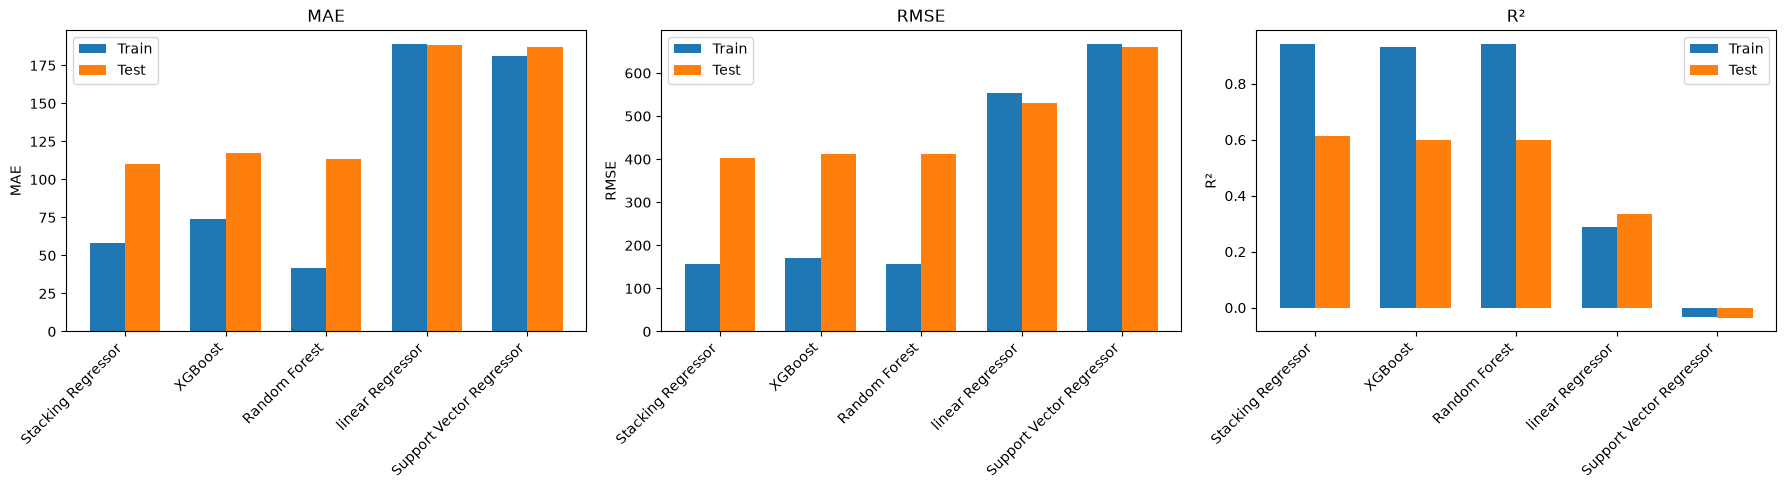

In [13]:
metrics = ["MAE", "RMSE", "R²"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(performance_df))
width = 0.35

for ax, metric in zip(axes, metrics):

    train_values = performance_df[f"Train {metric}"]
    test_values = performance_df[f"Test {metric}"]

    ax.bar(x - width/2, train_values, width, label="Train")
    ax.bar(x + width/2, test_values, width, label="Test")

    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(performance_df["Model"], rotation=45, ha="right")
    ax.set_ylabel(metric)
    ax.legend()

plt.tight_layout()
plt.show()

## Log Price Prediction Using the Full Dataset

In [14]:
# ============================================
# Evaluate Individual Models
# ============================================

results = []

for name, model in models.items():

    print(f"Evaluating {name}...")

    metrics = evaluate_model_price(
        model,
        X_train,
        y_log_train,
        X_test,
        y_log_test
    )

    metrics["Model"] = name

    results.append(metrics)

# ============================================
# Evaluate Stacking Regressor
# ============================================

print("Evaluating Stacking Regressor...")

stack_metrics = evaluate_model_price(
    stacking_regressor,
    X_train,
    y_log_train,
    X_test,
    y_log_test
)

stack_metrics["Model"] = "Stacking Regressor"

results.append(stack_metrics)

# ============================================
# Results Table
# ============================================

performance_df = pd.DataFrame(results)

performance_df = performance_df[
    [
        "Model",

        "Train MAE",
        "Test MAE",

        "Train MSE",
        "Test MSE",
        
        "Train RMSE",
        "Test RMSE",
        
        "Train R²",
        "Test R²",

        "R² Gap"
    ]
]

performance_df = performance_df.sort_values(
    by="Test R²",
    ascending=False
)

performance_df = performance_df.round(4)

print("\n========== Regression Model Performance ==========\n")
performance_df


Evaluating linear Regressor...
Evaluating Support Vector Regressor...
Evaluating Random Forest...
Evaluating XGBoost...
Evaluating Stacking Regressor...

========== Regression Model Performance ==========



,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R²,Test R²,R² Gap
3,XGBoost,71.3561,101.1102,84619.5709,172839.8053,290.8944,415.7401,0.8034,0.5891,0.2143
4,Stacking Regressor,55.1175,98.6218,68073.9904,174981.1902,260.9099,418.3075,0.8419,0.5840,0.2579
2,Random Forest,42.2170,101.3237,61932.2802,185182.3707,248.8620,430.3282,0.8561,0.5598,0.2964
0,linear Regressor,139.0106,133.1027,890290.9773,260855.8532,943.5523,510.7405,-1.0680,0.3799,-1.4479
1,Support Vector Regressor,151.0135,154.5892,375764.3999,360949.6102,612.9962,600.7908,0.1272,0.1419,-0.0147


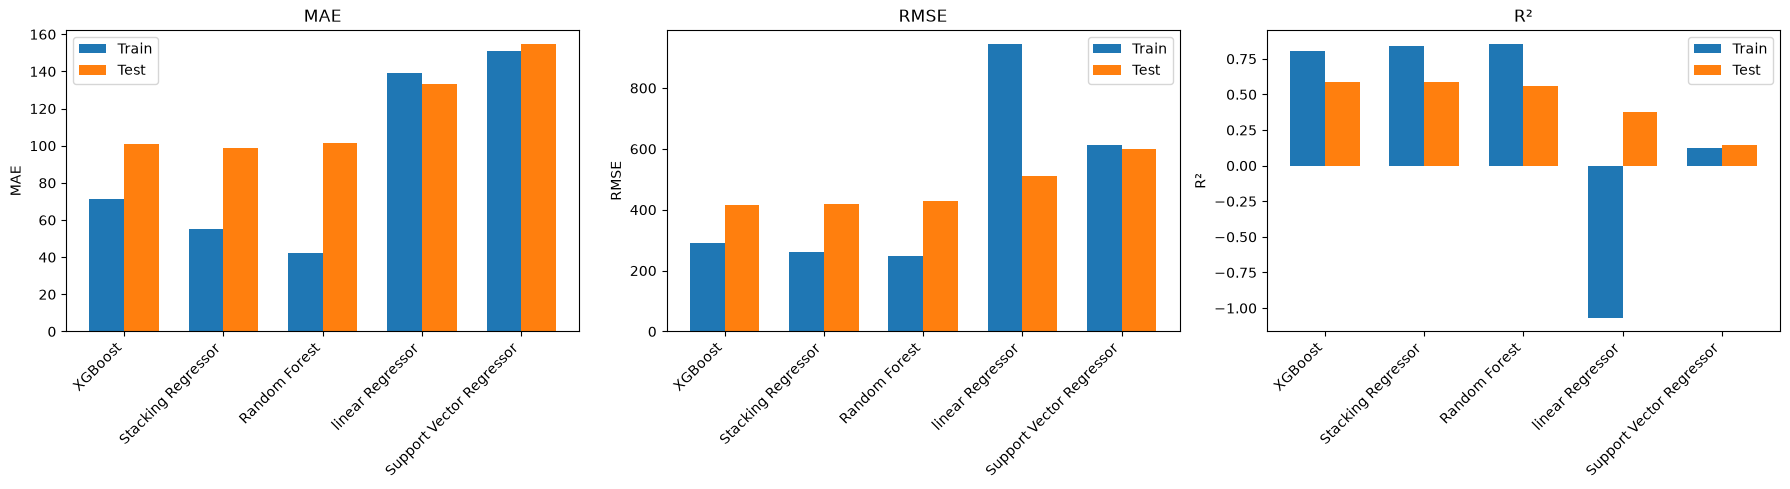

In [15]:

metrics = ["MAE", "RMSE", "R²"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(performance_df))
width = 0.35

for ax, metric in zip(axes, metrics):

    train_values = performance_df[f"Train {metric}"]
    test_values = performance_df[f"Test {metric}"]

    ax.bar(x - width/2, train_values, width, label="Train")
    ax.bar(x + width/2, test_values, width, label="Test")

    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(performance_df["Model"], rotation=45, ha="right")
    ax.set_ylabel(metric)
    ax.legend()

plt.tight_layout()
plt.show()

In [16]:
# Optional: save model

joblib.dump(stacking_regressor, "stacking_regressor.pkl")

['stacking_regressor.pkl']

## Price Prediction with Selected Outlier Removal

In [17]:
X_train = df_ml_no_outliers.drop(columns=["price_log", "price"])
y_train = df_ml_no_outliers["price"]
y_log_train = df_ml_no_outliers["price_log"]

In [18]:
# ============================================
# Evaluate Individual Models
# ============================================

results = []

for name, model in models.items():

    print(f"Evaluating {name}...")

    metrics = evaluate_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test
    )

    metrics["Model"] = name

    results.append(metrics)

# ============================================
# Evaluate Stacking Regressor
# ============================================

print("Evaluating Stacking Regressor...")

stack_metrics = evaluate_model(
    stacking_regressor,
    X_train,
    y_train,
    X_test,
    y_test
)

stack_metrics["Model"] = "Stacking Regressor"

results.append(stack_metrics)

# ============================================
# Results Table
# ============================================

performance_df = pd.DataFrame(results)

performance_df = performance_df[
    [
        "Model",

        "Train MAE",
        "Test MAE",

        "Train MSE",
        "Test MSE",
        
        "Train RMSE",
        "Test RMSE",
        
        "Train R²",
        "Test R²",

        "R² Gap"
    ]
]

performance_df = performance_df.sort_values(
    by="Test R²",
    ascending=False
)

performance_df = performance_df.round(4)

print("\n========== Regression Model Performance ==========\n")
performance_df


Evaluating linear Regressor...
Evaluating Support Vector Regressor...
Evaluating Random Forest...
Evaluating XGBoost...
Evaluating Stacking Regressor...

========== Regression Model Performance ==========



,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R²,Test R²,R² Gap
3,XGBoost,36.4757,129.7513,2992.5837,353412.0496,54.7045,594.4847,0.8255,0.1598,0.6656
4,Stacking Regressor,25.6103,128.1975,1534.4658,356411.9730,39.1723,597.0025,0.9105,0.1527,0.7578
2,Random Forest,16.9397,129.9182,743.1650,360708.1779,27.2611,600.5899,0.9567,0.1425,0.8142
0,linear Regressor,62.4128,150.8201,8224.8643,368896.0936,90.6910,607.3682,0.5203,0.1230,0.3973
1,Support Vector Regressor,82.5821,187.7786,16565.1628,438671.6710,128.7057,662.3229,0.0339,-0.0429,0.0767


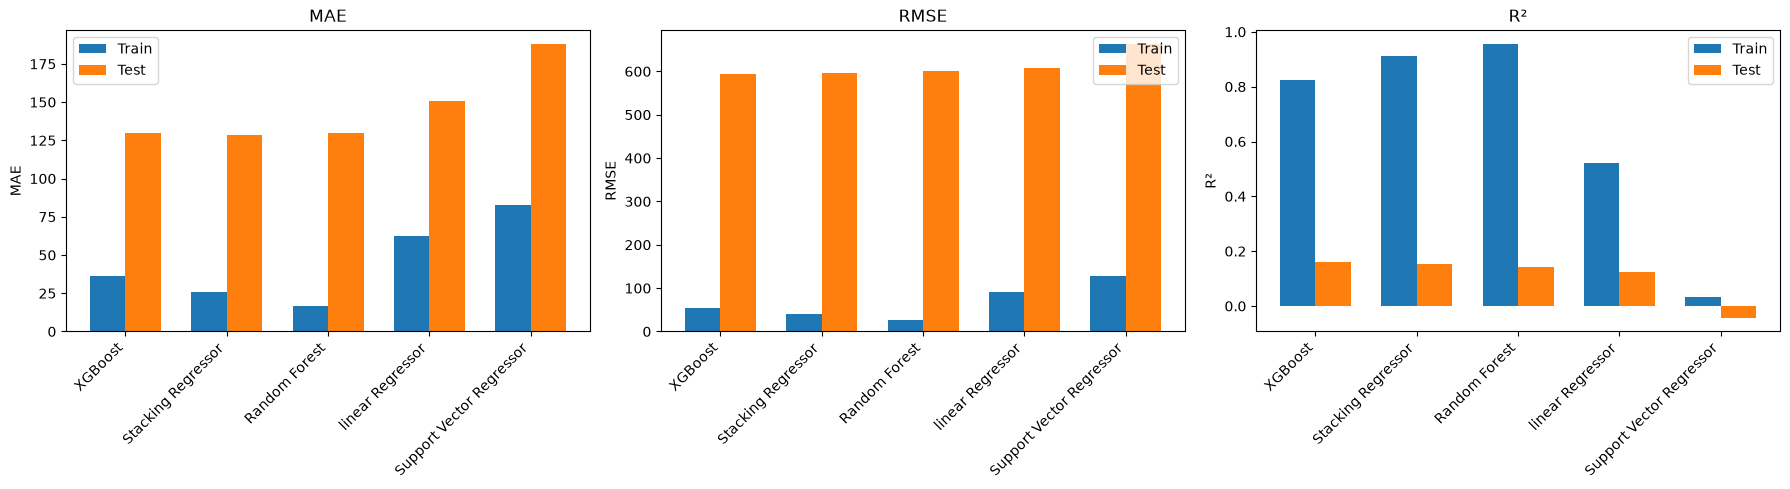

In [19]:

metrics = ["MAE", "RMSE", "R²"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(performance_df))
width = 0.35

for ax, metric in zip(axes, metrics):

    train_values = performance_df[f"Train {metric}"]
    test_values = performance_df[f"Test {metric}"]

    ax.bar(x - width/2, train_values, width, label="Train")
    ax.bar(x + width/2, test_values, width, label="Test")

    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(performance_df["Model"], rotation=45, ha="right")
    ax.set_ylabel(metric)
    ax.legend()

plt.tight_layout()
plt.show()

## Price Log Prediction with Selected Outlier Removal

In [20]:
# ============================================
# Evaluate Individual Models
# ============================================

results = []

for name, model in models.items():

    print(f"Evaluating {name}...")

    metrics = evaluate_model_price(
        model,
        X_train,
        y_log_train,
        X_test,
        y_log_test
    )

    metrics["Model"] = name

    results.append(metrics)

# ============================================
# Evaluate Stacking Regressor
# ============================================

print("Evaluating Stacking Regressor...")

stack_metrics = evaluate_model_price(
    stacking_regressor,
    X_train,
    y_log_train,
    X_test,
    y_log_test
)

stack_metrics["Model"] = "Stacking Regressor"

results.append(stack_metrics)

# ============================================
# Results Table
# ============================================

performance_df = pd.DataFrame(results)

performance_df = performance_df[
    [
        "Model",

        "Train MAE",
        "Test MAE",

        "Train MSE",
        "Test MSE",
        
        "Train RMSE",
        "Test RMSE",
        
        "Train R²",
        "Test R²",

        "R² Gap"
    ]
]

performance_df = performance_df.sort_values(
    by="Test R²",
    ascending=False
)

performance_df = performance_df.round(4)

print("\n========== Regression Model Performance ==========\n")
performance_df


Evaluating linear Regressor...
Evaluating Support Vector Regressor...
Evaluating Random Forest...
Evaluating XGBoost...
Evaluating Stacking Regressor...

========== Regression Model Performance ==========



,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R²,Test R²,R² Gap
0,linear Regressor,60.1286,144.6839,10072.0246,343097.9342,100.3595,585.7456,0.4126,0.1843,0.2282
3,XGBoost,35.9503,128.0354,3446.7510,355710.3682,58.7090,596.4146,0.7990,0.1544,0.6446
4,Stacking Regressor,25.4753,127.5234,1882.5016,359988.0480,43.3878,599.9900,0.8902,0.1442,0.7460
2,Random Forest,17.0379,130.0065,978.3701,365925.9814,31.2789,604.9182,0.9429,0.1301,0.8129
1,Support Vector Regressor,65.8666,160.9458,10961.7159,393625.8297,104.6982,627.3961,0.3607,0.0642,0.2965


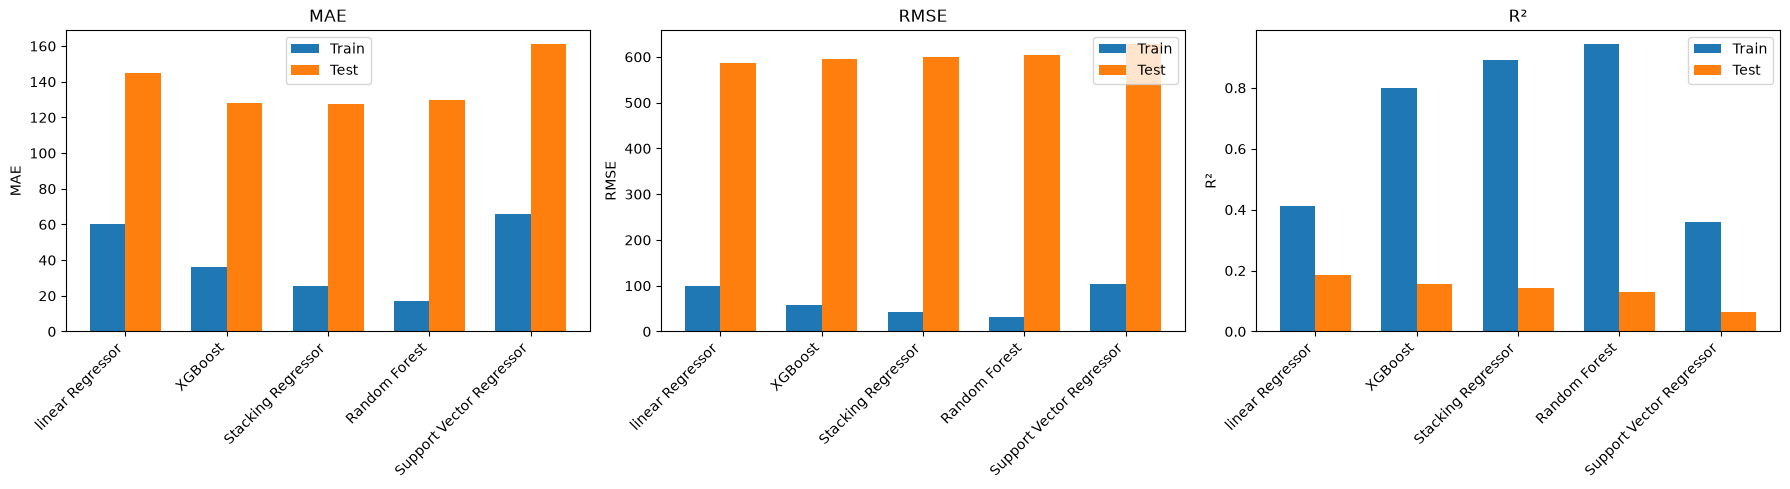

In [21]:

metrics = ["MAE", "RMSE", "R²"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(performance_df))
width = 0.35

for ax, metric in zip(axes, metrics):

    train_values = performance_df[f"Train {metric}"]
    test_values = performance_df[f"Test {metric}"]

    ax.bar(x - width/2, train_values, width, label="Train")
    ax.bar(x + width/2, test_values, width, label="Test")

    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(performance_df["Model"], rotation=45, ha="right")
    ax.set_ylabel(metric)
    ax.legend()

plt.tight_layout()
plt.show()

An experiment was done to compare between log price and ori price. The first was trained directly on the original Airbnb price, while the second model was trained using a log-transformed target, log1p(price). For the log-transformed model, predictions were converted back to the original price scale using expm1() before evaluation. Both models were evaluated on the same unseen test set using MAE, RMSE, and R².

The model trained using the original price target achieved better performance than the model trained using the log-transformed target, based on the lower MAE and RMSE and higher R² on the original price scale. Therefore, log transformation did not provide a performance improvement for this dataset, and the original price target was selected for the final model.

## Model Selection for Hyperparameter Tuning

Based on the initial model evaluation, **XGBoost** and the **Stacking Regressor** were selected for further hyperparameter tuning. The Stacking Regressor was selected because it achieved the strongest predictive performance during the initial model comparison, indicating that combining the predictions of multiple base learners could improve generalization performance.

XGBoost was selected as the second model because it provided strong predictive performance while maintaining a simpler and more unified model structure than the Stacking Regressor. This makes XGBoost more suitable for model interpretation and analysis, particularly through feature-importance methods. In contrast, interpreting a Stacking Regressor is more complex because its final prediction depends on multiple base learners and a meta-model.

Therefore, both models were retained for hyperparameter tuning: the **Stacking Regressor** to investigate whether ensemble learning could achieve the best predictive performance, and **XGBoost** to provide a strong-performing model with comparatively clearer interpretability.


## Feature Importance

Room type was the most influential feature in the XGBoost model, with `Entire home/apt` having the highest importance score (**0.6615**), followed by bedrooms (**0.1726**). The other room-type categories had considerably lower importance scores.

This indicates that the distinction between entire homes/apartments and other accommodation types provides substantial predictive information for Airbnb prices. However, feature importance represents predictive contribution rather than causal impact.
